In [ ]:
''' 
Possibilidade de gerar um script para rodar todos esses modelos 
usando a mesma distribuição de treino e teste 
Salvando por nome e método de feature selection e balanceamento

DADO 
- Tratamento de dados
- Balanceado e não balanceado

-Treino
-Teste

MODELOS

ABC - AdaBoostClassifier,
CBC - CatBoostClassifier,                      
DTC - DecisionTreeClassifier,
ETC - ExtraTreesClassifier,                   
GBC - GradientBoostingClassifier,
GNB - GaussianNB,
HGB - HistGradientBoostingClassifier,                 
KNN - KNeighborsClassifier,
LDA - LinearDiscriminantAnalysis,
LGBM - LGBMClassifier,
LR - LogisticRegression,
MLP - MLPClassifier,                           
PAC - PassiveAggressiveClassifier,                        
QDA - QuadraticDiscriminantAnalysis,
RDC - RidgeClassifier,                                 
RFC - RandomForestClassifier,
SGD - SGDClassifier,                           
SVM - SVC,
XGB - XGBClassifier,   



PARÂMETROS DOS MODELOS

MÉTRICAS

Confusion Matrix
Precisionn
Recall
F1 Score
Dice
AUC
Curva ROC PRC

GRÁFICOS

Curva ROC
Curva PRC
Curva de aprendizado
Curva de validação
Curva de calibração
Curva de Feature Importance
Curva de Confusão

ARQUIVO DO MODELO PKL
# Salvar o modelo em um arquivo

UPDATE FUTURO

StackingClassifier
BaggingClassifier
GridSearchCV
'''

In [1]:
# --- 1. Importação das Bibliotecas ---

import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from datetime import datetime
from IPython.display import display

from sklearn.linear_model import (
    LogisticRegression, 
    RidgeClassifier, 
    SGDClassifier,
    PassiveAggressiveClassifier
)
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    AdaBoostClassifier, 
    ExtraTreesClassifier, 
    HistGradientBoostingClassifier
)
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, 
    QuadraticDiscriminantAnalysis
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV

from sklearn.model_selection import (
    StratifiedKFold, 
    train_test_split,
)

from sklearn.metrics import (
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
)


In [ ]:
# vdado balanceado e desbalanceado
# Rodar todos os modelos 
# Comparar dados e confrontar com a literatura



In [2]:
# mapeando o diretório do projeto e do arquivo notebook 
diretorio_atual_projeto = os.getcwd() # Diretório atual do arquivo
notebook_dir_project_predict = os.path.normpath(f"{diretorio_atual_projeto}{os.sep}..{os.sep}..{os.sep}") + os.sep # Diretório do projeto
print(diretorio_atual_projeto)
print(notebook_dir_project_predict)

/home/ed/lgcm/projects/riskPredictionDeseases/dev/notebooks
/home/ed/lgcm/projects/riskPredictionDeseases/


In [ ]:
# nessa etapa vamos retirar as colunas 
    # '_MICHD', 
    # 'CVDINFR4', 
    # 'CVDCRHD4'




Models and Paameters

In [ ]:
# Dicionário de modelos

MODELS = {
        'ABC': AdaBoostClassifier,
        'CBC': CatBoostClassifier,                      
        'DTC': DecisionTreeClassifier,
        'ETC': ExtraTreesClassifier,                   
        'GBC': GradientBoostingClassifier,
        'GNB': GaussianNB,
        'HGB': HistGradientBoostingClassifier,                 
        'KNN': KNeighborsClassifier,
        'LDA': LinearDiscriminantAnalysis,
        'LGBM': LGBMClassifier,
        'LR': LogisticRegression,
        'MLP': MLPClassifier,                           
        'PAC': PassiveAggressiveClassifier,                        
        'QDA': QuadraticDiscriminantAnalysis,
        'RDC': RidgeClassifier,                                 
        'RFC': RandomForestClassifier,
        'SGD': SGDClassifier,                           
        'SVM': SVC,
        'XGB': XGBClassifier,   
    }

    # Dicionário de parâmetros a serem usados na instanciação

# --- ESTRUTURA DE PARÂMETROS ---
# Dicionário aninhado com parâmetros específicos para cada modelo
PARAMS_MODELS = {
    'Default': {'random_state': 42},
    'ABC': {'random_state': 42},
    'CBC': {'random_state': 42, 'verbose': 0, 'auto_class_weights': 'Balanced'},
    'DTC': {'random_state': 42, 'class_weight': 'balanced'},
    'ETC': {'random_state': 42, 'class_weight': 'balanced'},
    'GBC': {'random_state': 42}, # Não aceita class_weight
    'GNB': {},
    'HGB': {'random_state': 42}, # Aceita 'class_weight', mas de forma diferente. Usar padrão por enquanto.
    'KNN': {}, # Não aceita random_state
    'LDA': {},
    'LGBM': {'random_state': 42, 'class_weight': 'balanced'},
    'LR': {'random_state': 42, 'class_weight': 'balanced', 'max_iter': 1000},
    'MLP': {'random_state': 42, 'max_iter': 1000, 'hidden_layer_sizes': (100,)},
    'PAC': {'random_state': 42, 'class_weight': 'balanced'}, # Usará o 'loss' padrão ('hinge') que é válido
    'QDA': {},
    'RDC': {'random_state': 42, 'class_weight': 'balanced'},
    'RFC': {'random_state': 42, 'class_weight': 'balanced'},
    'SGD': {'random_state': 42, 'loss': 'log_loss', 'class_weight': 'balanced'}, # 'loss' específico para SGD
    'SVM': {'random_state': 42, 'class_weight': 'balanced', 'max_iter': 1000, 'probability': True},# Melhor usar true
    'XGB': {'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'},
}

#       verbose=0, auto_class_weights='Balanced', random_state=42), # verbose=0 para não imprimir o log de treino
#               (os parâmetros precisam de ajuste/tuning):
#               loss='log_loss' 
#               modelos de classificaão
# possivelmente , será necessário colocar o modelo e seus parâmetros em um dicionário único 
# assim poderemos criar versões de modelos com parâmetros diferentes 

MODELS_PARAMETERS = {
    'ABC': [AdaBoostClassifier,             {'Ada Boost Classifier':                {'random_state': 42}}, ],
    'CBC': [CatBoostClassifier,             {'Cat Boost Classifier':                {'random_state': 42, 'verbose': 0, 'auto_class_weights': 'Balanced'},}],                      
    'DTC': [DecisionTreeClassifier,         {'Decision Tree Classifier':            {'random_state': 42, 'class_weight': 'balanced'},}],
    'ETC': [ExtraTreesClassifier,           {'Extra Trees Classifier':              {'random_state': 42, 'class_weight': 'balanced'},}],                   
    'GBC': [GradientBoostingClassifier,     {'Gradient Boosting Classifier':        {'random_state': 42},}],
    'GNB': [GaussianNB,                     {'Gaussian NB':                         {},}],
    'HGB': [HistGradientBoostingClassifier, {'Hist Gradient Boosting Classifier':   {'random_state': 42},}],                 
    'KNN': [KNeighborsClassifier,           {'K Neighbors Classifier':              {},}],
    'LDA': [LinearDiscriminantAnalysis,     {'Linear Discriminant Analysis':        {},}],
    'LGBM': [LGBMClassifier,                {'LGBM Classifier':                     {'random_state': 42, 'class_weight': 'balanced'},}],
    'LR': [LogisticRegression,              {'Logistic Regression':                 {'random_state': 42, 'class_weight': 'balanced', 'max_iter': 1000},}],
    'MLP': [MLPClassifier,                  {'MLP Classifier':                      {'random_state': 42, 'max_iter': 1000, 'hidden_layer_sizes': (100,)},}],                           
    'PAC': [PassiveAggressiveClassifier,    {'Passive Aggressive Classifier':       {'random_state': 42, 'class_weight': 'balanced'},}],                        
    'QDA': [QuadraticDiscriminantAnalysis,  {'Quadratic Discriminant Analysis':     {},}],
    'RDC': [RidgeClassifier,                {'Ridge Classifier':                    {'random_state': 42, 'class_weight': 'balanced'},}],                                 
    'RFC': [RandomForestClassifier,         {'Random Forest Classifier':            {'random_state': 42, 'class_weight': 'balanced'},}],
    'SGD': [SGDClassifier,                  {'SGD Classifier':                      {'random_state': 42, 'loss': 'log_loss', 'class_weight': 'balanced'},}],                           
    'SVM': [SVC,                            {'SVC':                                 {'random_state': 42, 'class_weight': 'balanced', 'max_iter': 1000, 'probability': True},}],
    'XGB': [XGBClassifier,                  {'XGB Classifier':                      {'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'},}],  

}


In [ ]:
'''   
PARAMS = {
    
        'random_state': 42,
        'class_weight': 'balanced',
        'max_iter': 1000, 
        'probability': True, 
        'use_label_encoder': False, 
        'eval_metric': 'logloss',

        # para o xgd
        'loss': 'log_loss', 
        # 'class_weight': 'balanced', 

        # para o mlp
        'hidden_layer_sizes': (100,), 

        # para o cbc 
        'verbose': 0, 
        'auto_class_weights': 'Balanced', 
 
}

'''

In [5]:
# dia de  hoje para nomear a pasta do experimento
today = datetime.now().strftime("%Y_%m_%d")
print(today)
now = datetime.now().strftime("%Y_%m_%d-%H_%M")
print(now)

2025_07_01
2025_07_01-15_32


Dados

In [6]:
# Dados
# debalanceado 
df_limpo_final = pd.read_csv(f'{notebook_dir_project_predict}data{os.sep}output{os.sep}2023{os.sep}brfss_2023_cleaned_to_model.csv')

### Retirada das Colunas
df_limpo_final = df_limpo_final.drop(columns=[ 'CVDINFR4', 'CVDCRHD4'])
# as colunas retiradas acima foram usadas para produzir a _MICHD 
# assim retiramos para efeito de trinamento e teste 

### Definindo o nome da coluna alvo
NOME_COLUNA_ALVO = '_MICHD'

### Recategorização da coluna alvo

# 0 são os casos NEGATIVOS 
# 1 são os casos POSITIVOS

df_limpo_final[NOME_COLUNA_ALVO] = df_limpo_final[NOME_COLUNA_ALVO].replace({2.0: 0, 1.0: 1})



# Balanceado 1
# Balanceado 2

Regressão Logística

Formato de X (variáveis preditoras): (99799, 135)
Formato de y (variável alvo): (99799,)

Distribuição da variável alvo:
_MICHD
0.0    0.940571
1.0    0.059429
Name: proportion, dtype: float64

Formatos após a divisão:
X_train: (79839, 135)
X_test: (19960, 135)

Dados normalizados com sucesso.

Treinando o modelo de Regressão Logística...
Treinamento concluído.

--- Resultados da Avaliação ---

Acurácia do modelo: 0.9391


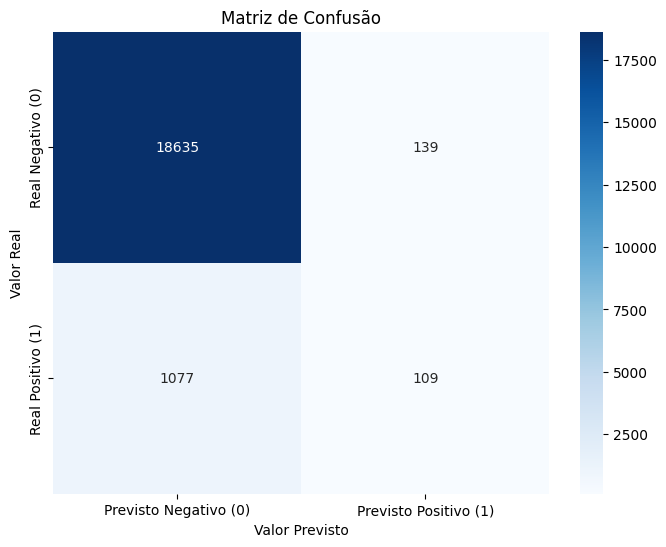


Relatório de Classificação:
              precision    recall  f1-score   support

Negativo (0)       0.95      0.99      0.97     18774
Positivo (1)       0.44      0.09      0.15      1186

    accuracy                           0.94     19960
   macro avg       0.69      0.54      0.56     19960
weighted avg       0.92      0.94      0.92     19960


Gerando Curva ROC...


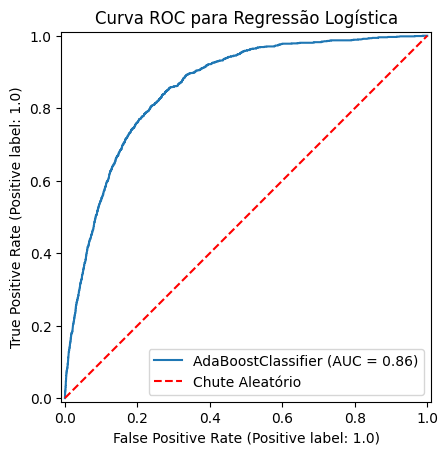

'coeficientes = pd.DataFrame(\n    selected_model.coef_[0],\n    index=X.columns,\n    columns=[\'Coeficiente\']\n).sort_values(by=\'Coeficiente\', ascending=False)\n\nprint("\n--- Interpretação do Modelo ---")\nprint("\n10 variáveis com maior impacto POSITIVO (aumentam o risco):")\ndisplay(coeficientes.head(10))\n\nprint("\n10 variáveis com maior impacto NEGATIVO (diminuem o risco):")\ndisplay(coeficientes.tail(10))\n'

In [8]:

X = df_limpo_final.drop(columns=[NOME_COLUNA_ALVO])
y = df_limpo_final[NOME_COLUNA_ALVO]

print("Formato de X (variáveis preditoras):", X.shape)
print("Formato de y (variável alvo):", y.shape)
print("\nDistribuição da variável alvo:")
print(y.value_counts(normalize=True))

# Dividir os dados em 80% para treino e 20% para teste.

# stratify=y é MUITO importante para dados desbalanceados. Ele garante que
# a proporção de 0s e 1s seja a mesma nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # Para reprodutibilidade
    stratify=y
)

print("\nFormatos após a divisão:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


# --- 2.3. Normalização/Escalonamento dos Dados (Scaling) ---

# A Regressão Logística funciona melhor quando os dados estão na mesma escala.
# Usaremos o StandardScaler.

# IMPORTANTE: O scaler é 'treinado' (fit) APENAS nos dados de treino.
# Depois, ele é usado para transformar tanto os dados de treino quanto os de teste.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Os resultados são arrays NumPy. Se preferir, pode convertê-los de volta para DataFrames.
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nDados normalizados com sucesso.")


# --- 3. Treinamento do Modelo de Regressão Logística ---

# Instanciar o modelo.
# class_weight='balanced' ajusta os pesos do modelo para dar mais importância
# à classe minoritária (casos positivos de risco cardíaco), o que é essencial.
# max_iter é aumentado para garantir a convergência em datasets maiores.
model_code = 'ABC'
model_class = MODELS_PARAMETERS[model_code][0]
params_aceitos = model_class().get_params().keys()
params_para_modelo = {k: v for k, v in MODELS_PARAMETERS[model_code][1].items() if k in params_aceitos}
selected_model = model_class(**params_para_modelo)


'''
# implementação onde se define o modelo e os parâmetros manualmente
selected_model = MODELS['LR'](
    class_weight='balanced', 
    random_state=42,
    max_iter=1000 # Aumentar se houver aviso de convergência
)'''

# Treinar o modelo usando os dados de treino escalonados
print("\nTreinando o modelo de Regressão Logística...")
selected_model.fit(X_train_scaled, y_train)
print("Treinamento concluído.")


# --- 4. Avaliação do Modelo ---

# Fazer predições nos dados de teste
y_pred = selected_model.predict(X_test_scaled)

# Calcular a acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"\n--- Resultados da Avaliação ---")
print(f"\nAcurácia do modelo: {acuracia:.4f}")

# --- 4.1. Matriz de Confusão ---
# Mostra os acertos e erros do modelo em detalhe.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Negativo (0)', 'Previsto Positivo (1)'],
            yticklabels=['Real Negativo (0)', 'Real Positivo (1)'])
plt.title('Matriz de Confusão')
plt.ylabel('Valor Real')
plt.xlabel('Valor Previsto')
plt.show()

# --- 4.2. Relatório de Classificação ---
# Fornece precisão, recall e F1-score para cada classe.
# - Precisão: Dos que o modelo previu como positivos, quantos eram realmente positivos.
# - Recall (Revocação/Sensibilidade): Dos que eram realmente positivos, quantos o modelo acertou.
# - F1-score: Média harmônica entre precisão e recall.
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))

# --- 4.3. Curva ROC e AUC ---
# A curva ROC mostra a capacidade do modelo de distinguir entre as classes.
# AUC (Área Sob a Curva) é uma métrica única que resume a performance.
# Quanto mais perto de 1, melhor. 0.5 é um chute aleatório.

print("\nGerando Curva ROC...")
RocCurveDisplay.from_estimator(selected_model, X_test_scaled, y_test)
plt.title('Curva ROC para Regressão Logística')
plt.plot([0, 1], [0, 1], 'r--', label='Chute Aleatório')
plt.legend()
plt.show()


# --- 5. Interpretação dos Coeficientes ---

# Os coeficientes mostram a importância que o modelo deu para cada variável.
# Coeficientes positivos aumentam a probabilidade da classe 1 (risco cardíaco).
# Coeficientes negativos diminuem a probabilidade.

'''coeficientes = pd.DataFrame(
    selected_model.coef_[0],
    index=X.columns,
    columns=['Coeficiente']
).sort_values(by='Coeficiente', ascending=False)

print("\n--- Interpretação do Modelo ---")
print("\n10 variáveis com maior impacto POSITIVO (aumentam o risco):")
display(coeficientes.head(10))

print("\n10 variáveis com maior impacto NEGATIVO (diminuem o risco):")
display(coeficientes.tail(10))
'''


# Todos os modelos

In [ ]:
# RODANDO OK
df_sem_vazamento = pd.read_csv(f'{notebook_dir_project_predict}data{os.sep}output{os.sep}2023{os.sep}brfss_2023_cleaned_to_model.csv')

df_sem_vazamento = df_sem_vazamento.drop(columns=[ 'CVDINFR4', 'CVDCRHD4'])
NOME_COLUNA_ALVO = '_MICHD'
df_sem_vazamento[NOME_COLUNA_ALVO] = df_sem_vazamento[NOME_COLUNA_ALVO].replace({2.0: 0, 1.0: 1})

try:
    if 'df_sem_vazamento' not in globals() or not isinstance(df_sem_vazamento, pd.DataFrame):
        raise NameError("'df_sem_vazamento' não encontrado.")
    
    # Separar Variáveis Preditoras (X) e Variável Alvo (y)
    # Garanta que a coluna alvo está recodificada para 0 (negativo) e 1 (positivo).
     
    
    X = df_sem_vazamento.drop(columns=[NOME_COLUNA_ALVO])
    y = df_sem_vazamento[NOME_COLUNA_ALVO]
    
    # Divisão em Dados de Treino e Teste de forma estratificada
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Normalização/Escalonamento dos Dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Dados preparados e divididos com sucesso.")
    print("Shape de X_train_scaled:", X_train_scaled.shape)

except NameError:
    print("ERRO CRÍTICO: DataFrame 'df_sem_vazamento' não encontrado.")
    print("Certifique-se de que a célula com o pré-processamento foi executada com sucesso.")
    dados_prontos = False
else:
    dados_prontos = True


# --- 3. Definição do Dicionário de Modelos ---

if dados_prontos:
   
    
    # Criar uma pasta para salvar os resultados, se não existir
    pasta_resultados = f'{notebook_dir_project_predict}data{os.sep}output{os.sep}2023{os.sep}resultados_modelos'
    if not os.path.exists(pasta_resultados):
        os.makedirs(pasta_resultados)
    print(f"\nResultados serão salvos na pasta: '{pasta_resultados}'")

    # --- 4. Loop de Treinamento e Avaliação (Salvando Localmente) ---
    
    resultados = []

    for name, model_class in tqdm(MODELS.items()):
        print(f"\n--- Processando Modelo: {name} ---")
        
        # Instanciar o modelo com os parâmetros compatíveis
        params_aceitos = model_class().get_params().keys()
        params_para_modelo = {k: v for k, v in PARAMS_MODELS[name].items() if k in params_aceitos}
        modelo = model_class(**params_para_modelo)
        
        # Treinamento
        start_time = time.time()
        modelo.fit(X_train_scaled, y_train)
        end_time = time.time()
        tempo_treino = end_time - start_time
        
        # Predições
        y_pred = modelo.predict(X_test_scaled)
        
        # Calcular probabilidades para AUC
        if hasattr(modelo, "predict_proba"):
            y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]
            auc_score = roc_auc_score(y_test, y_pred_proba)

        elif hasattr(modelo, "decision_function"):
            y_pred_proba = modelo.decision_function(X_test_scaled)
            auc_score = roc_auc_score(y_test, y_pred_proba)
            
        else:
            y_pred_proba = None
            auc_score = np.nan

        # Avaliação
        acuracia = accuracy_score(y_test, y_pred)
        precisao = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Armazenar resultados na lista
        resultados.append({
            'Modelo': name,
            'Acurácia': acuracia,
            'Precisão': precisao,
            'Recall': recall,
            'F1-Score': f1,
            'AUC': auc_score,
            'Tempo de Treino (s)': tempo_treino
        })
        
        print(f"Resultados para {name}: Acurácia={acuracia:.4f}, Recall={recall:.4f}, AUC={auc_score:.4f}")
        
        # --- Geração e Salvamento dos Gráficos ---
        
        # Gráfico 1: Matriz de Confusão
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Previsto Negativo (0)', 'Previsto Positivo (1)'],
                    yticklabels=['Real Negativo (0)', 'Real Positivo (1)'])
        plt.title(f'Matriz de Confusão - {name}')
        plt.ylabel('Valor Real')
        plt.xlabel('Valor Previsto')
        nome_arquivo_cm = os.path.join(pasta_resultados, f"{name}_matriz_confusao.png")
        plt.savefig(nome_arquivo_cm)
        plt.close() # Fecha a figura para não exibir no notebook agora
        print(f"Matriz de confusão salva em: {nome_arquivo_cm}")

        # Gráfico 2: Curva ROC
        if y_pred_proba is not None:
            plt.figure(figsize=(8, 6))
            display = RocCurveDisplay.from_estimator(modelo, X_test_scaled, y_test)
            plt.title(f'Curva ROC - {name}')
            plt.plot([0, 1], [0, 1], 'r--', label='Chute Aleatório')
            plt.legend()
            nome_arquivo_roc = os.path.join(pasta_resultados, f"{name}_curva_roc.png")
            plt.savefig(nome_arquivo_roc)
            plt.close()
            print(f"Curva ROC salva em: {nome_arquivo_roc}")

    # --- 5. Tabela Comparativa de Resultados ---

    df_resultados = pd.DataFrame(resultados).sort_values(by='Recall', ascending=False).reset_index(drop=True)
    
    # Salvar a tabela de resultados em um arquivo CSV
    caminho_tabela_csv = os.path.join(pasta_resultados, "01_comparacao_modelos.csv")
    df_resultados.to_csv(caminho_tabela_csv, index=False)
    
    print("\n\n--- Tabela Comparativa de Desempenho dos Modelos ---")
    print(f"Tabela de comparação salva em: {caminho_tabela_csv}")
    df_resultados # Exibe a tabela no notebook
    
else:
    print("\nModelagem não executada pois os dados não foram preparados.")



Dados preparados e divididos com sucesso.
Shape de X_train_scaled: (79839, 135)

Resultados serão salvos na pasta: '/home/ed/lgcm/projects/riskPredictionDeseases/data/output/2023/resultados_modelos'


  0%|          | 0/19 [00:00<?, ?it/s]


--- Processando Modelo: ABC ---
Resultados para ABC: Acurácia=0.9391, Recall=0.0919, AUC=0.8577
Matriz de confusão salva em: /home/ed/lgcm/projects/riskPredictionDeseases/data/output/2023/resultados_modelos/ABC_matriz_confusao.png


  5%|▌         | 1/19 [00:06<01:59,  6.66s/it]

Curva ROC salva em: /home/ed/lgcm/projects/riskPredictionDeseases/data/output/2023/resultados_modelos/ABC_curva_roc.png

--- Processando Modelo: CBC ---
Learning rate set to 0.066862
0:	learn: 0.5941666	total: 5.18ms	remaining: 5.18s
1:	learn: 0.5189558	total: 8.94ms	remaining: 4.46s
2:	learn: 0.4539099	total: 12.4ms	remaining: 4.13s
3:	learn: 0.4082782	total: 15.9ms	remaining: 3.95s
4:	learn: 0.3693660	total: 20.2ms	remaining: 4.02s
5:	learn: 0.3377653	total: 23.8ms	remaining: 3.94s
6:	learn: 0.3127703	total: 27.2ms	remaining: 3.86s
7:	learn: 0.2891518	total: 30.8ms	remaining: 3.82s
8:	learn: 0.2727828	total: 34.1ms	remaining: 3.76s
9:	learn: 0.2602138	total: 38.1ms	remaining: 3.77s
10:	learn: 0.2458268	total: 41.5ms	remaining: 3.73s
11:	learn: 0.2362844	total: 45ms	remaining: 3.7s
12:	learn: 0.2244985	total: 48.7ms	remaining: 3.7s
13:	learn: 0.2159617	total: 52.7ms	remaining: 3.71s
14:	learn: 0.2106879	total: 55.8ms	remaining: 3.67s
15:	learn: 0.2061923	total: 59.1ms	remaining: 3.63s

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [8]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC,Tempo de Treino (s)
0,SVM,0.059419,0.059419,1.000000,0.112173,0.537488,67.444205
1,QDA,0.425551,0.079309,0.817032,0.144584,0.638764,0.591910
2,RDC,0.779108,0.184576,0.795110,0.299603,0.860789,0.101361
3,LR,0.783367,0.187450,0.793423,0.303255,0.861734,2.172662
4,SGD,0.758717,0.168796,0.779933,0.277528,0.843430,2.203241
5,LGBM,0.795591,0.193692,0.771501,0.309645,0.860576,0.384281
6,GNB,0.747244,0.157222,0.746206,0.259721,0.814193,0.067317
7,PAC,0.668337,0.081614,0.446880,0.138021,0.600566,0.165379
8,LDA,0.929760,0.364662,0.245363,0.293347,0.853684,0.566558
9,MLP,0.900251,0.201631,0.229342,0.214596,0.728429,113.060701


In [ ]:
# dataset tratado
# treino
# Teste 
# Predição
# Avaliação
# Modelo Salvo pickle
# Gráficos

diretorio_atual_projeto = os.getcwd() # Diretório atual do arquivo
notebook_dir_project_predict = os.path.normpath(f"{diretorio_atual_projeto}{os.sep}..{os.sep}..{os.sep}") + os.sep # Diretório do projeto


path_treated_dataset = f'{notebook_dir_project_predict}data{os.sep}output{os.sep}2023'

path_training_dataset = f'{notebook_dir_project_predict}data{os.sep}intermediate{os.sep}2023{os.sep}train_test'
path_test_dataset = f'{notebook_dir_project_predict}data{os.sep}intermediate{os.sep}2023{os.sep}train_test'

path_model = f'{notebook_dir_project_predict}data{os.sep}output{os.sep}model_files'
path_results = f'{notebook_dir_project_predict}data{os.sep}output{os.sep}model_files'



# TESTE implementar dicionári ode parametros

In [ ]:


# --- 2. Preparação dos Dados ---
# Certifique-se de que o seu DataFrame final e sem vazamento de dados já está carregado.
try:
    df_sem_vazamento = pd.read_csv(f'{notebook_dir_project_predict}data{os.sep}output{os.sep}2023{os.sep}brfss_2023_cleaned_to_model.csv')
    df_sem_vazamento = df_sem_vazamento.drop(columns=['CVDINFR4', 'CVDCRHD4'])
    NOME_COLUNA_ALVO = '_MICHD'
    df_sem_vazamento[NOME_COLUNA_ALVO] = df_sem_vazamento[NOME_COLUNA_ALVO].replace({2.0: 0, 1.0: 1})
    
    if 'df_sem_vazamento' not in globals() or not isinstance(df_sem_vazamento, pd.DataFrame):
        raise NameError("'df_sem_vazamento' não encontrado.")
    
    X = df_sem_vazamento.drop(columns=[NOME_COLUNA_ALVO])
    y = df_sem_vazamento[NOME_COLUNA_ALVO]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Dados preparados e divididos com sucesso.")
    dados_prontos = True

except NameError:
    print("ERRO CRÍTICO: DataFrame 'df_sem_vazamento' não encontrado.")
    dados_prontos = False


# --- 3. Definição dos Dicionários de Modelos e Parâmetros ---

if dados_prontos:
    
    
    pasta_resultados = "resultados_modelos"
    if not os.path.exists(pasta_resultados):
        os.makedirs(pasta_resultados)
    print(f"\nResultados serão salvos na pasta: '{pasta_resultados}'")

    # --- 4. Loop de Treinamento e Avaliação ---
    
    resultados = []

    for name, model_class in tqdm(MODELS.items()):
        print(f"\n--- Processando Modelo: {name} ---")
        
        # --- Lógica de instanciação CORRIGIDA ---
        # Pega os parâmetros para o modelo atual, ou os parâmetros padrão se não houver específicos
        params_para_modelo = PARAMS_POR_MODELO.get(name, PARAMS_POR_MODELO['Default'])
        modelo = model_class(**params_para_modelo)
        
        # Treinamento e avaliação (resto do código igual)
        start_time = time.time()
        modelo.fit(X_train_scaled, y_train)
        end_time = time.time()
        tempo_treino = end_time - start_time
        
        y_pred = modelo.predict(X_test_scaled)
        
        y_scores = None
        if hasattr(modelo, "predict_proba"):
            y_scores = modelo.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(modelo, "decision_function"):
            y_scores = modelo.decision_function(X_test_scaled)
        
        auc_score = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

        resultados.append({
            'Modelo': name,
            'Acurácia': accuracy_score(y_test, y_pred),
            'Precisão': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'AUC': auc_score,
            'Tempo de Treino (s)': tempo_treino
        })
        
        print(f"Resultados para {name}: Acurácia={accuracy_score(y_test, y_pred):.4f}, Recall={recall_score(y_test, y_pred):.4f}, AUC={auc_score:.4f}")
        
        # Geração e Salvamento dos Gráficos (resto do código igual)
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Previsto Negativo (0)', 'Previsto Positivo (1)'], yticklabels=['Real Negativo (0)', 'Real Positivo (1)'])
        plt.title(f'Matriz de Confusão - {name}'); plt.ylabel('Valor Real'); plt.xlabel('Valor Previsto')
        plt.savefig(os.path.join(pasta_resultados, f"{name}_matriz_confusao.png"))
        plt.close()

        if y_scores is not None:
            display = RocCurveDisplay.from_predictions(y_test, y_scores, name=name)
            plt.title(f'Curva ROC - {name}'); plt.plot([0, 1], [0, 1], 'r--', label='Chute Aleatório'); plt.legend()
            plt.savefig(os.path.join(pasta_resultados, f"{name}_curva_roc.png"))
            plt.close()

    # --- 5. Tabela Comparativa de Resultados ---
    df_resultados = pd.DataFrame(resultados).sort_values(by='Recall', ascending=False).reset_index(drop=True)
    df_resultados.to_csv(os.path.join(pasta_resultados, "01_comparacao_modelos.csv"), index=False)
    
    print("\n\n--- Tabela Comparativa de Desempenho dos Modelos ---")
    display(df_resultados)
    
else:
    print("\nModelagem não executada pois os dados não foram preparados.")



ERRO CRÍTICO: DataFrame 'df_sem_vazamento' não encontrado.

Modelagem não executada pois os dados não foram preparados.


# Script preliminar pois o RDC precisa de outros dados para a curva ROC

In [ ]:
# --- 1. Importação das Bibliotecas Necessárias ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time # Para medir o tempo de treinamento
import os # Para criar pastas

# Modelos
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier

# Ferramentas de Avaliação e Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, RocCurveDisplay)
from IPython.display import display # Para melhor exibição de tabelas no notebook

# --- 2. Preparação dos Dados (Assumindo que já foram carregados e limpos) ---

# Certifique-se de que o seu DataFrame final e sem vazamento de dados já está carregado.
# O nome dele deve ser 'df_sem_vazamento' para este script funcionar diretamente.
try:
    if 'df_sem_vazamento' not in globals() or not isinstance(df_sem_vazamento, pd.DataFrame):
        raise NameError("'df_sem_vazamento' não encontrado.")
    
    # Separar Variáveis Preditoras (X) e Variável Alvo (y)
    # Garanta que a coluna alvo está recodificada para 0 (negativo) e 1 (positivo).
    NOME_COLUNA_ALVO = '_MICHD_processed' 
    
    X = df_sem_vazamento.drop(columns=[NOME_COLUNA_ALVO])
    y = df_sem_vazamento[NOME_COLUNA_ALVO]
    
    # Divisão em Dados de Treino e Teste de forma estratificada
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Normalização/Escalonamento dos Dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Dados preparados e divididos com sucesso.")
    print("Shape de X_train_scaled:", X_train_scaled.shape)

except NameError:
    print("ERRO CRÍTICO: DataFrame 'df_sem_vazamento' não encontrado.")
    print("Certifique-se de que a célula com o pré-processamento foi executada com sucesso.")
    dados_prontos = False
else:
    dados_prontos = True


# --- 3. Definição do Dicionário de Modelos e Parâmetros ---

if dados_prontos:
    MODELS = {
        'ABC': AdaBoostClassifier,
        'CBC': CatBoostClassifier,
        'DTC': DecisionTreeClassifier,
        'ETC': ExtraTreesClassifier,
        'GBC': GradientBoostingClassifier,
        'GNB': GaussianNB,
        'KNN': KNeighborsClassifier,
        'LDA': LinearDiscriminantAnalysis,
        'LGBM': LGBMClassifier,
        'LR': LogisticRegression,
        'MLP': MLPClassifier,
        'QDA': QuadraticDiscriminantAnalysis,
        'RDC': RidgeClassifier,
        'RFC': RandomForestClassifier,
        'SGD': SGDClassifier,
        'SVM': SVC,
        'XGB': XGBClassifier,   
    }

    PARAMS = {
        'random_state': 42,
        'class_weight': 'balanced',
        'max_iter': 1000, 
        'probability': True, # Para SVM calcular probabilidades
        'use_label_encoder': False, 
        'eval_metric': 'logloss',
        'loss': 'log_loss', # Para SGD
        'hidden_layer_sizes': (100,), # Para MLP
        'verbose': 0, # Para CatBoost
        'auto_class_weights': 'Balanced', # Para CatBoost
    }
    
    # Criar uma pasta para salvar os resultados, se não existir
    pasta_resultados = "resultados_modelos"
    if not os.path.exists(pasta_resultados):
        os.makedirs(pasta_resultados)
    print(f"\nResultados serão salvos na pasta: '{pasta_resultados}'")

    # --- 4. Loop de Treinamento e Avaliação ---
    
    resultados = []

    for name, model_class in tqdm(MODELS.items()):
        print(f"\n--- Processando Modelo: {name} ---")
        
        # Instanciar o modelo com os parâmetros compatíveis
        params_aceitos = model_class().get_params().keys()
        params_para_modelo = {k: v for k, v in PARAMS.items() if k in params_aceitos}
        modelo = model_class(**params_para_modelo)
        
        # Treinamento
        start_time = time.time()
        modelo.fit(X_train_scaled, y_train)
        end_time = time.time()
        tempo_treino = end_time - start_time
        
        # Predições
        y_pred = modelo.predict(X_test_scaled)
        
        # --- Lógica atualizada para calcular AUC ---
        y_scores = None # Inicializa como None
        
        if hasattr(modelo, "predict_proba"):
            # Usa predict_proba se disponível (maioria dos modelos)
            y_scores = modelo.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(modelo, "decision_function"):
            # Usa decision_function se predict_proba não estiver disponível (ex: Ridge, SVM)
            y_scores = modelo.decision_function(X_test_scaled)
        
        # Calcula AUC se tivermos uma pontuação
        if y_scores is not None:
            auc_score = roc_auc_score(y_test, y_scores)
        else:
            auc_score = np.nan # Para modelos que não têm nenhum dos dois métodos

        # Avaliação
        acuracia = accuracy_score(y_test, y_pred)
        precisao = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Armazenar resultados
        resultados.append({'Modelo': name, 'Acurácia': acuracia, 'Precisão': precisao,
                           'Recall': recall, 'F1-Score': f1, 'AUC': auc_score,
                           'Tempo de Treino (s)': tempo_treino})
        
        print(f"Resultados para {name}: Acurácia={acuracia:.4f}, Recall={recall:.4f}, AUC={auc_score:.4f}")
        
        # --- Geração e Salvamento dos Gráficos ---
        
        # Matriz de Confusão
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Previsto Negativo (0)', 'Previsto Positivo (1)'],
                    yticklabels=['Real Negativo (0)', 'Real Positivo (1)'])
        plt.title(f'Matriz de Confusão - {name}')
        plt.ylabel('Valor Real'); plt.xlabel('Valor Previsto')
        nome_arquivo_cm = os.path.join(pasta_resultados, f"{name}_matriz_confusao.png")
        plt.savefig(nome_arquivo_cm)
        plt.close()
        print(f"Matriz de confusão salva em: {nome_arquivo_cm}")

        # Curva ROC
        if y_scores is not None:
            # Usar 'from_predictions' para plotar a partir dos scores calculados
            display = RocCurveDisplay.from_predictions(y_test, y_scores, name=name)
            plt.title(f'Curva ROC - {name}')
            plt.plot([0, 1], [0, 1], 'r--', label='Chute Aleatório')
            plt.legend()
            nome_arquivo_roc = os.path.join(pasta_resultados, f"{name}_curva_roc.png")
            plt.savefig(nome_arquivo_roc)
            plt.close()
            print(f"Curva ROC salva em: {nome_arquivo_roc}")

    # --- 5. Tabela Comparativa de Resultados ---
    df_resultados = pd.DataFrame(resultados).sort_values(by='Recall', ascending=False).reset_index(drop=True)
    caminho_tabela_csv = os.path.join(pasta_resultados, "01_comparacao_modelos.csv")
    df_resultados.to_csv(caminho_tabela_csv, index=False)
    
    print("\n\n--- Tabela Comparativa de Desempenho dos Modelos ---")
    print(f"Tabela de comparação salva em: {caminho_tabela_csv}")
    display(df_resultados)
    
else:
    print("\nModelagem não executada pois os dados não foram preparados.")

